# Continued pretraining behavior — PD

Descriptive trajectories and coverage, grouped by base, learning rate, L2-SP and adaptation. Set `CREDITPFN_VIZ_RUN` to choose a phase; the default is `cpt_main_v4`. Historical `exp1` records remain exploratory. Monitoring uses four ensemble members and up to 2,000 rows per table; final benchmark results are in the results notebook.

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
REPO = Path(os.getcwd()).resolve()
# pyproject.toml, not a module path: src/visualize/ used to be
# src/utils/ and this loop then walked past the repo root.
while not (REPO / 'pyproject.toml').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

# `display` is an IPython builtin. src/utils/run_notebooks.py executes this file as
# a plain script to rebuild All_Results.md, where it is not — so import it.
from IPython.display import display

import pandas as pd
from src.visualize.figures import FigureSaver
from src.visualize import style
from src.visualize.training_viz import (
    load_run_manifest, load_epoch_history, load_all_epoch_histories,
    training_overview, trial_leaderboard, failed_trials,
    plot_loss_curve, plot_lr_schedule, plot_metric_curves, plot_grid_summary,
    plot_epoch_time, plot_trial_dashboard,
    plot_loss_overlay, plot_metric_overlay, plot_overfitting_diagnostic,
    plot_final_metric_bar, plot_lr_effect, plot_lora_effect,
    plot_metric_heatmap, plot_base_ranking,
    plot_pareto_time_vs_metric, plot_epoch_time_overlay,
    plot_convergence_speed,
    plot_weight_drift, plot_per_dataset_loss,
)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
TRACK = 'pd'    # this notebook is fixed to the PD track
sink = FigureSaver('1.1. training_pd')

# One style for every figure in this project.
style.apply()

# Experiment 1 targets its own per-split output (exp1_s00 … exp1_s07). Point every
# loader — training, eval, and the text summaries built on them — at run 'cpt_main_v4', so
# run-8's older artefacts in output/ are never mixed in.
from src.visualize import training_viz as _tv, eval_viz as _ev
_tv.use_run(os.environ.get('CREDITPFN_VIZ_RUN', 'cpt_main_v4'))
_ev.use_run(os.environ.get('CREDITPFN_VIZ_RUN', 'cpt_main_v4'))

from src.visualize.trajectories import load_trajectories, trajectory_effects, plot_trajectories


## 1 — Trial coverage

Count completed, interrupted and failed attempts before interpreting effects. A missing result is unavailable, not a zero effect.

""


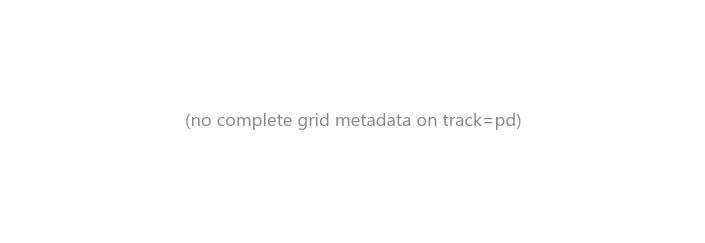

In [2]:
manifest = load_run_manifest(TRACK)
overview = training_overview(TRACK)
display(manifest['status'].value_counts().rename('attempts').to_frame() if not manifest.empty else manifest)
sink.save(plot_grid_summary(TRACK, coverage=True), 'grid_coverage', caption='Recorded completed trials per recipe across available dataset partitions. Empty cells have no completed measurement.')

## 2 — Fixed-update behavior

Each value is paired with update 0 for the same trial and dataset. Positive changes mean improvement: AUC increase for PD or fractional RMSE reduction for LGD. Datasets receive equal weight; seed repetitions are averaged within each dataset first. Curves with incomplete observations at a milestone are left missing. Read partial runs together with coverage; these are descriptive monitoring results, not final benchmark estimates.

In [3]:
trajectories = load_trajectories(TRACK)
effects = trajectory_effects(trajectories, TRACK)
display(effects.groupby(['base', 'sampling', 'updates'])['dataset'].nunique().rename('datasets').to_frame() if not effects.empty else effects)
for sampling in ('one_sample', 'full_pass', 'accumulate'):
    for base, fig in plot_trajectories(TRACK, sampling=sampling).items():
        sink.save(fig, f'trajectory_{base}_{sampling}', caption=f'Change from update zero for {base}, using {sampling.replace("_", " ")}. Panels distinguish full updates and a frozen backbone; colors denote peak learning rate and line styles denote L2-SP. Dataset effects receive equal weight. Missing milestone observations leave gaps.')

""


## 3 — Training diagnostics

Loss and epoch timing help locate numerical failures and processing bottlenecks. A flat or poor held-out curve is an observation, not an automatic reason to stop a descriptive trial.

""


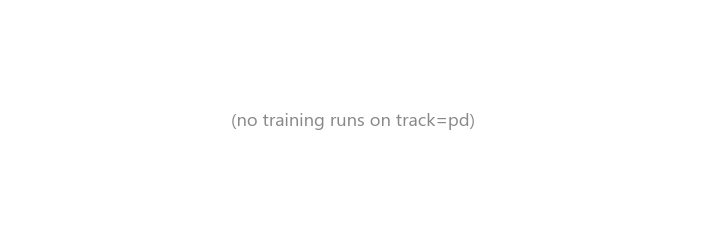

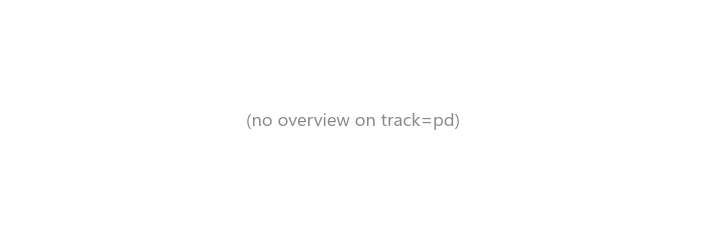

In [4]:
sink.save(plot_loss_overlay(TRACK, only_ok=False), 'loss_overlay', caption='Training loss by progress for recorded trials, including unsuccessful attempts where a history is available.')
sink.save(plot_epoch_time_overlay(TRACK), 'epoch_time_overlay', caption='Median epoch duration per recorded trial. Dataset sampling modes can perform different numbers of optimizer updates per epoch.')
display(failed_trials(TRACK))

## 4 — Text summary

In [5]:
print('1 — Trial coverage')
print(manifest['status'].value_counts().to_string() if not manifest.empty else 'No recorded attempts for this run.')
print('\n2 — Fixed-update behavior')
print(f'{len(trajectories)} trajectory rows; {len(effects)} finite dataset/update effects.')
print('Positive effect = AUC increase (PD) or fractional RMSE reduction (LGD).')
print('\n3 — Training diagnostics')
print(f'{len(overview)} recorded trial identities; failed attempts remain visible.')
print('\n4 — Figures')
print(sink.summary())

1 — Trial coverage
No recorded attempts for this run.

2 — Fixed-update behavior
0 trajectory rows; 0 finite dataset/update effects.
Positive effect = AUC increase (PD) or fractional RMSE reduction (LGD).

3 — Training diagnostics
0 recorded trial identities; failed attempts remain visible.

4 — Figures
1.1. training_pd: 3 figures -> output/figures/1.1. training_pd
  01  grid_coverage
  02  loss_overlay
  03  epoch_time_overlay
